<a href="https://colab.research.google.com/github/aini43325018-ui/2025_algoritma_dan_pemrograman/blob/Kecerdasan-Buatan---Semester-2/AI_Jobsheet_10_Naive_Bayes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Import Library

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix
from matplotlib.colors import ListedColormap

## Load Dataset

In [ ]:
# Membaca dataset dengan pemisah titik koma
df_nb = pd.read_csv('iklan_sosmed.csv', delimiter=';')
print("Dataset Iklan Sosmed berhasil dimuat!")

Dataset Iklan Sosmed berhasil dimuat!


## Menampilkan Properti Data

In [ ]:
print("--- 5 Baris Pertama ---")
display(df_nb.head())

print("\n--- Informasi Dataset ---")
df_nb.info()

--- 5 Baris Pertama ---


,ID,Jenis_Kelamin,Umur,Gaji,Transaksi
0,15624510,Pria,19,285000000,0
1,15810944,Pria,35,300000000,0
2,15668575,Wanita,26,645000000,0
3,15603246,Wanita,27,855000000,0
4,15804002,Pria,19,1140000000,0



--- Informasi Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   ID             400 non-null    int64 
 1   Jenis_Kelamin  400 non-null    object
 2   Umur           400 non-null    int64 
 3   Gaji           400 non-null    int64 
 4   Transaksi      400 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 15.8+ KB


## Cek Missing Value dan Duplikasi Data

In [ ]:
print("--- Jumlah Missing Value ---")
print(df_nb.isnull().sum())

print(f"\nJumlah data duplikat: {df_nb.duplicated().sum()} baris")

# Menghapus data duplikat jika ada
df_nb = df_nb.drop_duplicates()

--- Jumlah Missing Value ---
ID               0
Jenis_Kelamin    0
Umur             0
Gaji             0
Transaksi        0
dtype: int64

Jumlah data duplikat: 0 baris


## Cek Korelasi dengan Kolom Transaksi

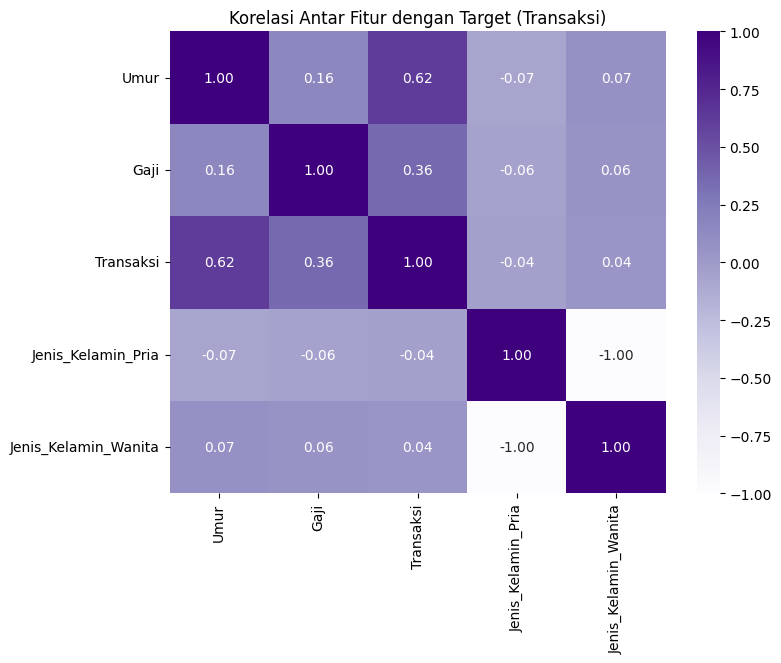


Korelasi spesifik terhadap kolom 'Transaksi':
Transaksi               1.000000
Umur                    0.622454
Gaji                    0.362083
Jenis_Kelamin_Wanita    0.042469
Jenis_Kelamin_Pria     -0.042469
Name: Transaksi, dtype: float64


In [ ]:
# Menghapus kolom 'ID' (tidak berguna) dan mengubah 'Jenis_Kelamin' jadi angka
df_nb_corr = pd.get_dummies(df_nb.drop('ID', axis=1, errors='ignore'))

# Cek korelasi antar fitur
plt.figure(figsize=(8, 6))
sns.heatmap(df_nb_corr.corr(), annot=True, cmap='Purples', fmt=".2f")
plt.title("Korelasi Antar Fitur dengan Target (Transaksi)")
plt.show()

print("\nKorelasi spesifik terhadap kolom 'Transaksi':")
print(df_nb_corr.corr()['Transaksi'].sort_values(ascending=False))

## Train Test Split dan Normalisasi

In [ ]:
# Sesuai modul, kita hanya mengambil kolom Umur dan Gaji sebagai fitur (X)
X_nb = df_nb[['Umur', 'Gaji']].values
y_nb = df_nb['Transaksi'].values

# Split data (80% training, 20% testing, random_state=99 sesuai modul)
X_train_nb, X_test_nb, y_train_nb, y_test_nb = train_test_split(X_nb, y_nb, test_size=0.2, random_state=99)

# Feature Scaling menggunakan MinMaxScaler (Khas untuk Naive Bayes di Jobsheet ini)
sc = MinMaxScaler()
X_train_nb = sc.fit_transform(X_train_nb)
X_test_nb = sc.transform(X_test_nb)

print("Ukuran X_train:", X_train_nb.shape)
print("Ukuran X_test:", X_test_nb.shape)
print("Data selesai dinormalisasi!")

Ukuran X_train: (320, 2)
Ukuran X_test: (80, 2)
Data selesai dinormalisasi!


## Melatih Model Naive Bayes Classifier

Akurasi Model Naïve Bayes: 87.50%

Confusion Matrix:


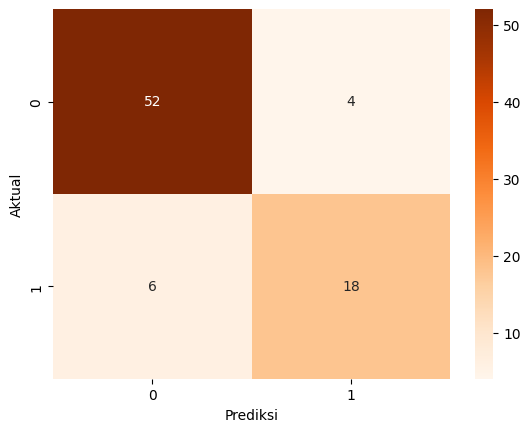

In [ ]:
# Membuat objek Gaussian Naive Bayes dan melatih model
nb_model = GaussianNB()
nb_model.fit(X_train_nb, y_train_nb)

# Prediksi data test
y_pred_nb = nb_model.predict(X_test_nb)

# Menghitung akurasi dan menampilkan Confusion Matrix
acc_nb = accuracy_score(y_test_nb, y_pred_nb)
print(f"Akurasi Model Naïve Bayes: {acc_nb * 100:.2f}%\n")

print("Confusion Matrix:")
cm_nb = confusion_matrix(y_test_nb, y_pred_nb)
sns.heatmap(cm_nb, annot=True, fmt="d", cmap="Oranges")
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.show()

## Melakukan Visualisasi Data Train dan Data Test

/tmp/ipykernel_1558/2987034915.py:10: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


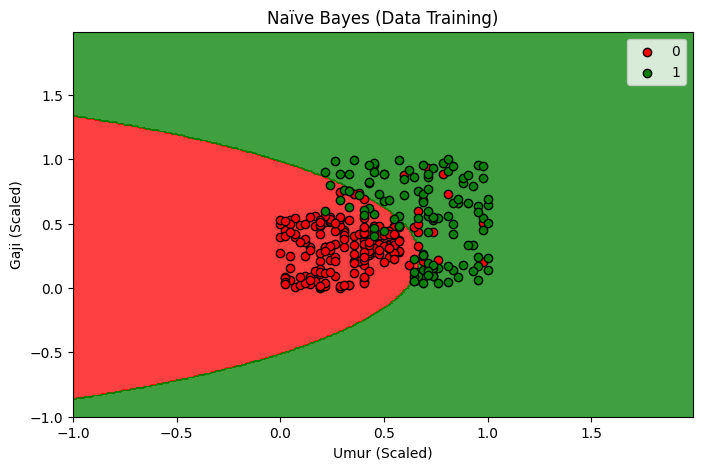

/tmp/ipykernel_1558/2987034915.py:10: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


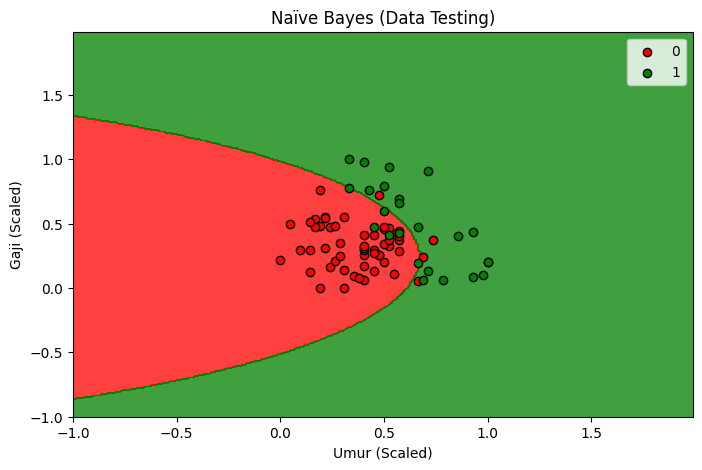

In [ ]:
# Fungsi bantuan untuk visualisasi contour plot
def plot_nb_boundary(X_set, y_set, classifier, title):
    X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 1, stop = X_set[:, 0].max() + 1, step = 0.01),
                         np.arange(start = X_set[:, 1].min() - 1, stop = X_set[:, 1].max() + 1, step = 0.01))
    plt.contourf(X1, X2, classifier.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
                 alpha = 0.75, cmap = ListedColormap(('red', 'green')))
    plt.xlim(X1.min(), X1.max())
    plt.ylim(X2.min(), X2.max())
    for i, j in enumerate(np.unique(y_set)):
        plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],
                    c = ListedColormap(('red', 'green'))(i), label = j, edgecolor='black')
    plt.title(title)
    plt.xlabel('Umur (Scaled)')
    plt.ylabel('Gaji (Scaled)')
    plt.legend()
    plt.show()

# Menjalankan fungsi untuk Data Training
plt.figure(figsize=(8,5))
plot_nb_boundary(X_train_nb, y_train_nb, nb_model, 'Naïve Bayes (Data Training)')

# Menjalankan fungsi untuk Data Testing
plt.figure(figsize=(8,5))
plot_nb_boundary(X_test_nb, y_test_nb, nb_model, 'Naïve Bayes (Data Testing)')

## Hyperparameter Tuning Naive Bayes

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import MinMaxScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

# 1. Load Data & Persiapan
df_nb = pd.read_csv('iklan_sosmed.csv', delimiter=';')
X_nb = df_nb[['Umur', 'Gaji']].values
y_nb = df_nb['Transaksi'].values

# 2. Split & Normalisasi
X_train_nb, X_test_nb, y_train_nb, y_test_nb = train_test_split(X_nb, y_nb, test_size=0.2, random_state=99)
sc_nb = MinMaxScaler()
X_train_nb = sc_nb.fit_transform(X_train_nb)
X_test_nb = sc_nb.transform(X_test_nb)

# 3. Menerapkan Grid Search
print("Mencari parameter terbaik untuk Naïve Bayes...")
param_grid_nb = {
    'var_smoothing': np.logspace(0, -9, num=100)
}

grid_nb = GridSearchCV(GaussianNB(), param_grid_nb, cv=5, verbose=1, scoring='accuracy')
grid_nb.fit(X_train_nb, y_train_nb)

# 4. Hasil Tuning
print("\n=== HASIL TUNING NAÏVE BAYES ===")
print("Parameter Terbaik:", grid_nb.best_params_)
y_pred_nb = grid_nb.predict(X_test_nb)
print(f"Akurasi Naïve Bayes setelah Tuning: {accuracy_score(y_test_nb, y_pred_nb) * 100:.2f}%")

Mencari parameter terbaik untuk Naïve Bayes...
Fitting 5 folds for each of 100 candidates, totalling 500 fits

=== HASIL TUNING NAÏVE BAYES ===
Parameter Terbaik: {'var_smoothing': np.float64(0.008111308307896872)}
Akurasi Naïve Bayes setelah Tuning: 87.50%
